# Laboratorio de regresión - 5

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 18/09/2026       |
| **Expediente** | 757806           |

## Validación

Hemos estado usando `train_test_split` en nuestros modelos anteriores.

¿Por qué?

Para medir el modelo con datos que no vio al entrenar. Si lo mides con los mismos datos con los que se ajusto el error sale optimista, el modelo ya los conoce. El test es lo unico que dice si de verdad generaliza

Si la muestra es un subset de la población y queremos generalizar sobre la población, ¿no sería mejor utilizar todos los datos al entrenar un modelo?

Para el modelo final si, entre mas datos mejor. El problema es que si entrenas con todo ya no te queda nada con que comprobar si generaliza o si se sobreajusto

Por eso primero se parte y se valida, y si el modelo generaliza bien entonces si se junta todo y se reentrena. Eso es justo lo que hace la validacion cruzada, usar todos los datos pero nunca al mismo tiempo para entrenar y probar

El propósito de volver a muestrear dentro de nuestro dataset es tener una idea de qué tan buena podría ser la generalización de nuestro modelo. Imagina un dataset ya separado en dos mitades. Utilizas la primera mitad para entrenar el modelo y pruebas en la segunda mitad; la segunda mitad eran datos invisibles para el modelo al momento de entrenar. Esto nos lleva a tres escenario típicos:

1. Si el modelo hace buenas predicciones en la segunda mitad, significa que la primera mitad era "suficiente" para generalizar.
2. Si el modelo no hace buenas predicciones en la segunda mitad, pero sí en la primera mitad, podría ser que había información importante en la segunda mitad que debió haber sido tomada en cuenta al entrenar, o un problema de overfitting.
3. Si el modelo no hace buenas predicciones en la segunda mitad, y tampoco en la primera mitad, se tendrían que revisar los factores y/o el modelo seleccionado.

El caso ideal sería el 1, pero por estadística los errores y varianzas tienen como entrada el número de muestas, por lo que tenemos menos seguridad de nuestros resutados al usar menos muestras. Si vemos que el modelo generaliza bien podemos unir de nuevo el dataset y entrenar sobre el dataset completo.

En el caso 2 está el problema de que no podemos saber qué información es necesaria para el entrenamiento apropiado del modelo; esto nos lleva a pensar que debemos usar el dataset completo para entrenar, pero esto nos lleva al mismo problema de no saber si el modelo puede generalizar.

El problema sólo incrementa si se tienen hiperparámetros en el modelo (e.g. $\lambda$ en regularización).

## Leave-One-Out Cross Validation

Este método de validación es una colección de $n$ `train-test-split`. Teniendo un dataset de $n$ muestras, la lógica es:
1. Saca una muestra del dataset.
2. Entrena tu modelo con las $n-1$ muestras.
3. Evalúa tu modelo en la muestra que quedó fuera con el métrico que más se ajuste a la aplicación.
4. Regresa la muestra al dataset.
5. Repite 1-4 con muestras diferentes hasta haber hecho el procedimiento $n$ veces para $n$ muestras.
6. Calcula la media y desviación estándar de los métricos guardados.

Con los resultados del proceso de validación podemos saber qué tan bueno podría ser el modelo seleccionado con los datos (con/sin transformaciones).

### Ejercicio 1

Utiliza el dataset `Motor Trend Car Road Tests`. Elimina la columna `model` y entrena 32 modelos diferentes utilizando Leave-One-Out Cross Validation con target `mpg`. Utiliza MSE como métrico.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_excel("Motor Trend Car Road Tests.xlsx", sheet_name="mtcars")

nombres = df["model"]
df = df.drop(columns="model")

X = df.drop(columns="mpg")
y = df["mpg"]

print(X.shape)

(32, 10)


In [3]:
numerical_cols = ["disp", "hp", "drat", "wt", "qsec"]
categorical_cols = ["cyl", "gear", "carb"]
boolean_cols = ["vs", "am"]

# handle_unknown ignore porque hay un carro con carb 6 que es el unico, si queda fuera el one hot no conoce esa categoria
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    remainder="drop",
)

pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])

In [4]:
# Leave one out, se entrena 32 veces dejando un carro fuera cada vez

loo = LeaveOneOut()
mse_loo = []

for train_idx, test_idx in loo.split(X):
    pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred = pipeline.predict(X.iloc[test_idx])
    mse_loo.append(mean_squared_error(y.iloc[test_idx], y_pred))

mse_loo = np.array(mse_loo)

print("Modelos entrenados:", len(mse_loo))
print("MSE promedio:", mse_loo.mean())
print("Desviacion:", mse_loo.std())
print("Minimo:", mse_loo.min(), " Maximo:", mse_loo.max())

Modelos entrenados: 32
MSE promedio: 23.087232231992875
Desviacion: 43.313251427751226
Minimo: 0.44384487769627157  Maximo: 230.065521753169


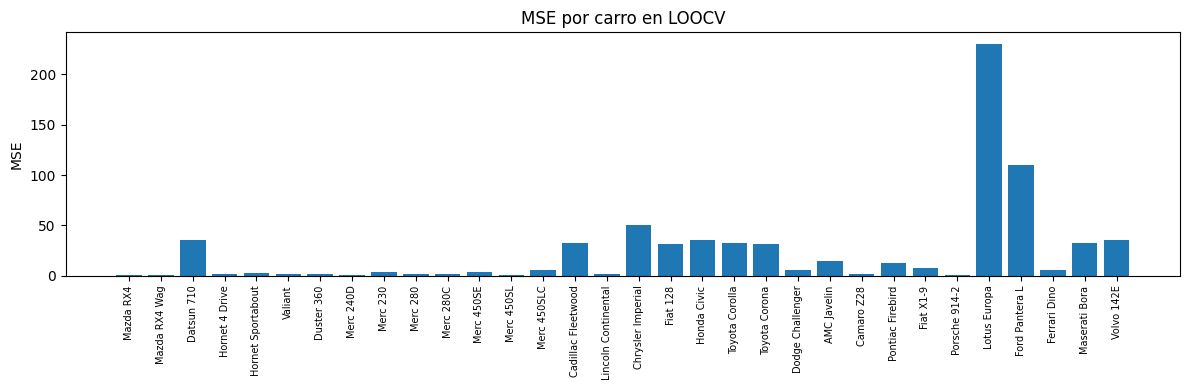

In [5]:
# MSE de cada carro cuando le toco quedar fuera

plt.figure(figsize=(12, 4))
plt.bar(range(len(mse_loo)), mse_loo)
plt.xticks(range(len(mse_loo)), nombres, rotation=90, fontsize=7)
plt.ylabel("MSE")
plt.title("MSE por carro en LOOCV")
plt.tight_layout()
plt.show()

In [6]:
# Los que peor salieron

pd.DataFrame({"carro": nombres, "mpg": y, "mse": mse_loo.round(2)}).sort_values("mse", ascending=False).head(5)

,carro,mpg,mse
27,Lotus Europa,30.4,230.07
28,Ford Pantera L,15.8,109.70
16,Chrysler Imperial,14.7,50.49
18,Honda Civic,30.4,35.89
31,Volvo 142E,21.4,35.71


In [7]:
# Para comparar, el MSE si se entrena y se mide con todo

pipeline.fit(X, y)
print("MSE con todos los datos:", mean_squared_error(y, pipeline.predict(X)))

MSE con todos los datos: 3.762583499914403


Interpreta.

El MSE promedio de los 32 modelos sale de 23.1 con una desviacion de 43.3, o sea que varia muchisimo de un carro a otro. Casi todos quedan abajo de 10 pero el Lotus Europa se va a 230 y el Ford Pantera a 110, esos dos solos jalan el promedio

Pasa porque son carros raros, el Lotus es el mas ligero y rinde 30 mpg, cuando queda fuera el modelo no tiene otro parecido con que aprender. Con 32 datos cualquier carro atipico pesa mucho

Lo importante es la comparacion con el MSE entrenando con todo, que da 3.8. El error real al generalizar es como 6 veces mas grande de lo que parece si se mide con los mismos datos. Un RMSE de 4.8 mpg contra una desviacion de mpg de 6 dice que el modelo si sirve pero no tanto como aparentaba

## K-Folds Cross-Validation

El dataset `Motor Trend Car Road Tests` sólo tiene 32 muestras, y utilizar un modelo sencillo de regresión múltiple hace que usar LOOCV sea muy rápido. El dataset `California Housing` tiene $20640$ muestras para $9$ columnas, entonces realizar un ajuste sobre una transformación o sobre el modelo y luego calcular el impacto esperado podría tomar más tiempo.

La solución propuesta es dividir el dataset en *k* folds (partes iguales), ajustar en *k-1* folds y probar en el restante.

### Ejercicio 2
Utiliza el dataset `California Housing` y haz K-folds Cross Validation con 10 folds. Utiliza el MSE como métrico.

In [8]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print("Dataset Shape:", housing.data.shape, housing.target.shape)
print("Dataset Features:", housing.feature_names)
print("Dataset Target:", housing.target_names)
X = housing.data
y = housing.target

Dataset Shape: (20640, 8) (20640,)
Dataset Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset Target: ['MedHouseVal']


In [9]:
pipeline_ch = Pipeline(steps=[("esc", StandardScaler()), ("model", LinearRegression())])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_kf = []

for k, (train_idx, test_idx) in enumerate(kf.split(X)):
    pipeline_ch.fit(X[train_idx], y[train_idx])
    y_pred = pipeline_ch.predict(X[test_idx])
    mse_kf.append(mean_squared_error(y[test_idx], y_pred))
    print("Fold", k + 1, "-> MSE:", round(mse_kf[-1], 4), " (", len(test_idx), "casas de prueba )")

mse_kf = np.array(mse_kf)

print()
print("MSE promedio:", mse_kf.mean())
print("Desviacion:", mse_kf.std())

Fold 1 -> MSE: 0.559  ( 2064 casas de prueba )
Fold 2 -> MSE: 0.5531  ( 2064 casas de prueba )
Fold 3 -> MSE: 0.4812  ( 2064 casas de prueba )
Fold 4 -> MSE: 0.5742  ( 2064 casas de prueba )
Fold 5 -> MSE: 0.489  ( 2064 casas de prueba )
Fold 6 -> MSE: 0.5284  ( 2064 casas de prueba )
Fold 7 -> MSE: 0.5512  ( 2064 casas de prueba )
Fold 8 -> MSE: 0.4748  ( 2064 casas de prueba )
Fold 9 -> MSE: 0.5644  ( 2064 casas de prueba )
Fold 10 -> MSE: 0.55  ( 2064 casas de prueba )

MSE promedio: 0.5325266619260604
Desviacion: 0.03522806775489762


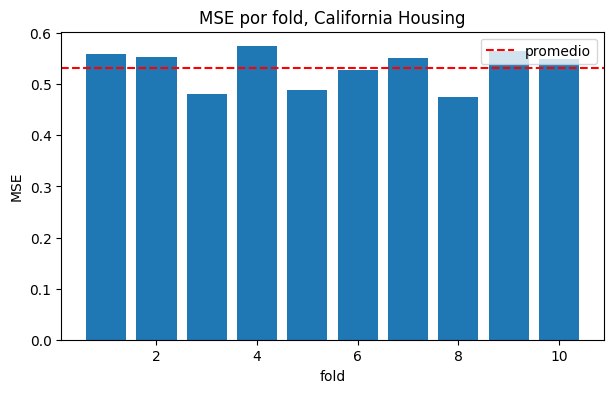

In [10]:
plt.figure(figsize=(7, 4))
plt.bar(range(1, 11), mse_kf)
plt.axhline(mse_kf.mean(), color="red", linestyle="--", label="promedio")
plt.xlabel("fold")
plt.ylabel("MSE")
plt.title("MSE por fold, California Housing")
plt.legend()
plt.show()

In [11]:
# Para comparar con la escala de la y, el target esta en cientos de miles de dolares

print("RMSE:", np.sqrt(mse_kf.mean()))
print("Media de y:", y.mean(), " Desviacion de y:", y.std())

RMSE: 0.7297442441883734
Media de y: 2.0685581690891475  Desviacion de y: 1.153928204041225


Interpreta.

Los 10 folds salen muy parecidos, entre 0.47 y 0.57, promedio 0.53 y desviacion de solo 0.035. Con 20 mil casas cada fold tiene 2064 de prueba y ya no hay casas raras que jalen el resultado, por eso es tan estable comparado con el LOOCV de los carros

Con K folds solo se entrenaron 10 modelos en vez de 20640, mucho mas rapido y da practicamente la misma info

El RMSE es 0.73, o sea 73 mil dolares de error tipico en casas que valen 207 mil en promedio con desviacion de 115 mil. La regresion lineal explica como la mitad de la variacion, no esta mal para 8 columnas pero se nota que faltan cosas o que la relacion no es tan lineal

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3